# ============================================================
# Experiment No. 09
# Title: K-Means Clustering
# ============================================================

In [56]:

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# 1. Load Dataset

In [57]:
df = pd.read_csv("/home/anjali/Downloads/Mall_Customers.csv")


print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows of dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape:
(200, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory

# 2. Select Features

In [23]:
# We don't use CustomerID because it is just an identifier.
# We also don't use Gender for this basic practical.

X = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]


print("\nSelected Features:")
print(X.head())



Selected Features:
   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6
3   23                  16                      77
4   31                  17                      40


# 3. Feature Scaling

In [25]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 4. Elbow Method


WCSS Values:
K = 1  WCSS = 600.0
K = 2  WCSS = 389.39
K = 3  WCSS = 295.21
K = 4  WCSS = 205.23
K = 5  WCSS = 168.25
K = 6  WCSS = 133.87
K = 7  WCSS = 117.01
K = 8  WCSS = 103.87
K = 9  WCSS = 93.09
K = 10  WCSS = 82.39


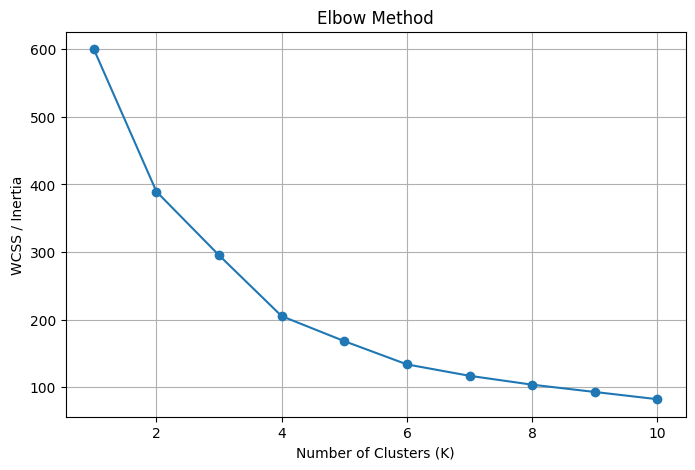

In [41]:
wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


# Display WCSS values
print("\nWCSS Values:")

for k, value in enumerate(wcss, start=1):
    print("K =", k, " WCSS =", round(value, 2))


# Plot Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.grid(True)

plt.show()

# 5. Apply K-Means

In [43]:
# From the elbow graph, select K.
# For this dataset, K = 5 is commonly used.

k = 5

kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    random_state=42,
    n_init=10
)


# Train the model
cluster_labels = kmeans.fit_predict(X_scaled)



# 6. Add Cluster Labels to Dataset

In [45]:
df["Cluster"] = cluster_labels


print("\nDataset with Cluster Labels:")
print(df.head(20))




Dataset with Cluster Labels:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0            1    Male   19                  15                      39   
1            2    Male   21                  15                      81   
2            3  Female   20                  16                       6   
3            4  Female   23                  16                      77   
4            5  Female   31                  17                      40   
5            6  Female   22                  17                      76   
6            7  Female   35                  18                       6   
7            8  Female   23                  18                      94   
8            9    Male   64                  19                       3   
9           10  Female   30                  19                      72   
10          11    Male   67                  19                      14   
11          12  Female   35                  19                      9

# 7. Display Cluster Centroids

In [47]:
centroids_scaled = kmeans.cluster_centers_

centroids = scaler.inverse_transform(centroids_scaled)

centroid_df = pd.DataFrame(
    centroids,
    columns=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

print("\nCluster Centroids:")
print(centroid_df)




Cluster Centroids:
         Age  Annual Income (k$)  Spending Score (1-100)
0  46.250000           26.750000               18.350000
1  25.185185           41.092593               62.240741
2  32.875000           86.100000               81.525000
3  39.871795           86.102564               19.358974
4  55.638298           54.382979               48.851064


# 8. Silhouette Score


In [49]:
sil_score = silhouette_score(
    X_scaled,
    cluster_labels
)

print("\nSilhouette Score:")
print(round(sil_score, 3))



Silhouette Score:
0.417


# 9. Visualize Clusters

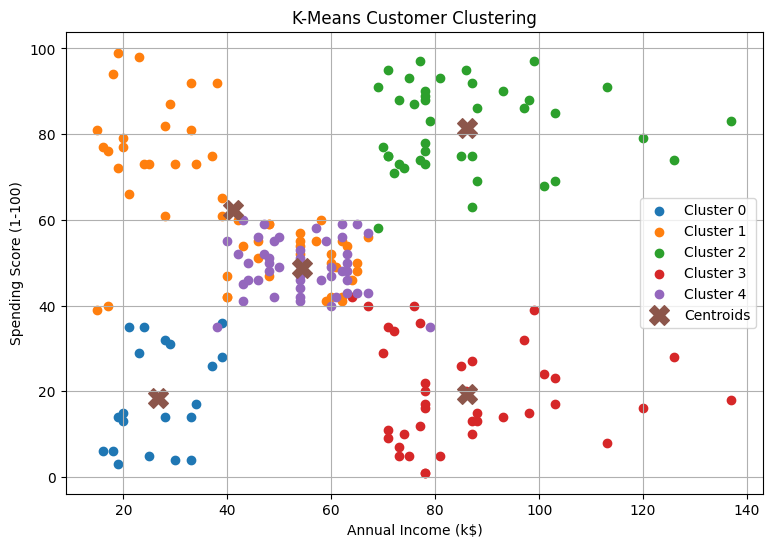

In [51]:
plt.figure(figsize=(9, 6))

for cluster in range(k):

    cluster_data = df[df["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {cluster}"
    )


# Plot centroids
plt.scatter(
    centroid_df["Annual Income (k$)"],
    centroid_df["Spending Score (1-100)"],
    marker="X",
    s=200,
    label="Centroids"
)


plt.title("K-Means Customer Clustering")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.grid(True)

plt.show()

# 10. Cluster Analysis

In [53]:

print("\nNumber of Customers in Each Cluster:")

print(
    df["Cluster"].value_counts().sort_index()
)


# Mean values for each cluster
cluster_summary = df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()


print("\nCluster Summary:")
print(cluster_summary.round(2))


Number of Customers in Each Cluster:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

Cluster Summary:
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        46.25               26.75                   18.35
1        25.19               41.09                   62.24
2        32.88               86.10                   81.53
3        39.87               86.10                   19.36
4        55.64               54.38                   48.85


# 11. Save Result

In [55]:
df.to_csv(
    "Mall_Customers_with_Clusters.csv",
    index=False
)

print(
    "\nClustered dataset saved as "
    "'Mall_Customers_with_Clusters.csv'"
)

print("\nExperiment completed successfully.")


Clustered dataset saved as 'Mall_Customers_with_Clusters.csv'

Experiment completed successfully.
